# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


In [1]:
# ======================================
# EKSPERIMEN MSML - PIMA INDIANS DIABETES DATASET
# Nama       : Rahma Hidayati Fitrah
# Email      : rahmahidayatif@gmail.com
# ID Dicoding: APC189D6X0054
# ======================================

"""
PERKENALAN DATASET
------------------
Dataset: Pima Indians Diabetes Database
Sumber : UCI Machine Learning Repository / Kaggle
URL    : https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

Deskripsi:
Dataset ini digunakan untuk memprediksi secara medis apakah seorang pasien terkena diabetes atau tidak, berdasarkan pengukuran diagnostik tertentu. All patients here are females at least 21 years old of Pima Indian heritage.

Fitur (8 input numerik):
- Pregnancies: Jumlah kehamilan
- Glucose: Konsentrasi glukosa plasma
- BloodPressure: Tekanan darah diastolik (mm Hg)
- SkinThickness: Ketebalan lipatan kulit trisep (mm)
- Insulin: Insulin serum 2 jam (mu U/ml)
- BMI: Indeks Massa Tubuh (berat dalam kg/(tinggi dalam m)^2)
- DiabetesPedigreeFunction: Fungsi silsilah diabetes (riwayat keluarga)
- Age: Umur (tahun)

Target (1 output biner):
- Outcome: Status diabetes (0 = Tidak Diabetes, 1 = Diabetes)

Jumlah data: 768 baris, 9 kolom
Task: Binary Classification
"""
print("Perkenalan dataset selesai")

Perkenalan dataset selesai


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import sklearn
import warnings
warnings.filterwarnings('ignore')

print("Semua library berhasil diimport")
print(f"Pandas version      : {pd.__version__}")
print(f"NumPy version       : {np.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

Semua library berhasil diimport
Pandas version      : 2.2.2
NumPy version       : 2.0.2
Scikit-learn version: 1.6.1


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
df = pd.read_csv('diabetes.csv')

df.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df.to_csv('diabetes_raw.csv', index=False)

print("Dataset Diabetes berhasil dimuat dan disimpan sebagai raw!")
print(f"Total data: {df.shape[0]} baris, {df.shape[1]} kolom")
print("\n5 baris pertama:")
df.head()

Dataset Diabetes berhasil dimuat dan disimpan sebagai raw!
Total data: 768 baris, 9 kolom

5 baris pertama:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
print("INFO DATASET")
df.info()

INFO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [5]:
print("MISSING VALUES")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

print("\nDATA DUPLIKAT")
print(f"Jumlah duplikat: {df.duplicated().sum()}")

print("\nSTATISTIK DESKRIPTIF")
df.describe()

MISSING VALUES
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total missing values: 0

DATA DUPLIKAT
Jumlah duplikat: 0

STATISTIK DESKRIPTIF


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


DISTRIBUSI KELAS TARGET (Outcome)
Outcome
0    500
1    268
Name: count, dtype: int64


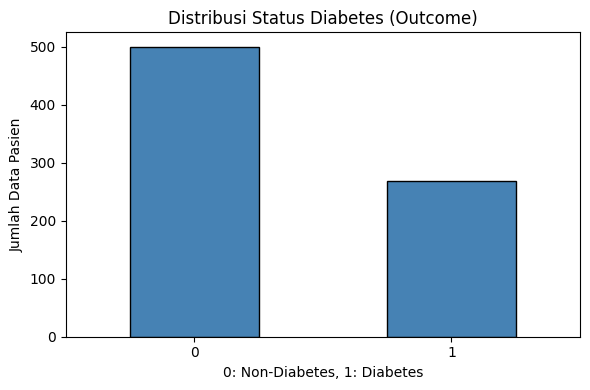

Visualisasi distribusi target baru berhasil disimpan


In [6]:
print("DISTRIBUSI KELAS TARGET (Outcome)")
print(df['Outcome'].value_counts().sort_index())

plt.figure(figsize=(6, 4))
df['Outcome'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribusi Status Diabetes (Outcome)')
plt.xlabel('0: Non-Diabetes, 1: Diabetes')
plt.ylabel('Jumlah Data Pasien')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('distribusi_target.png', dpi=150)
plt.show()
print("Visualisasi distribusi target baru berhasil disimpan")

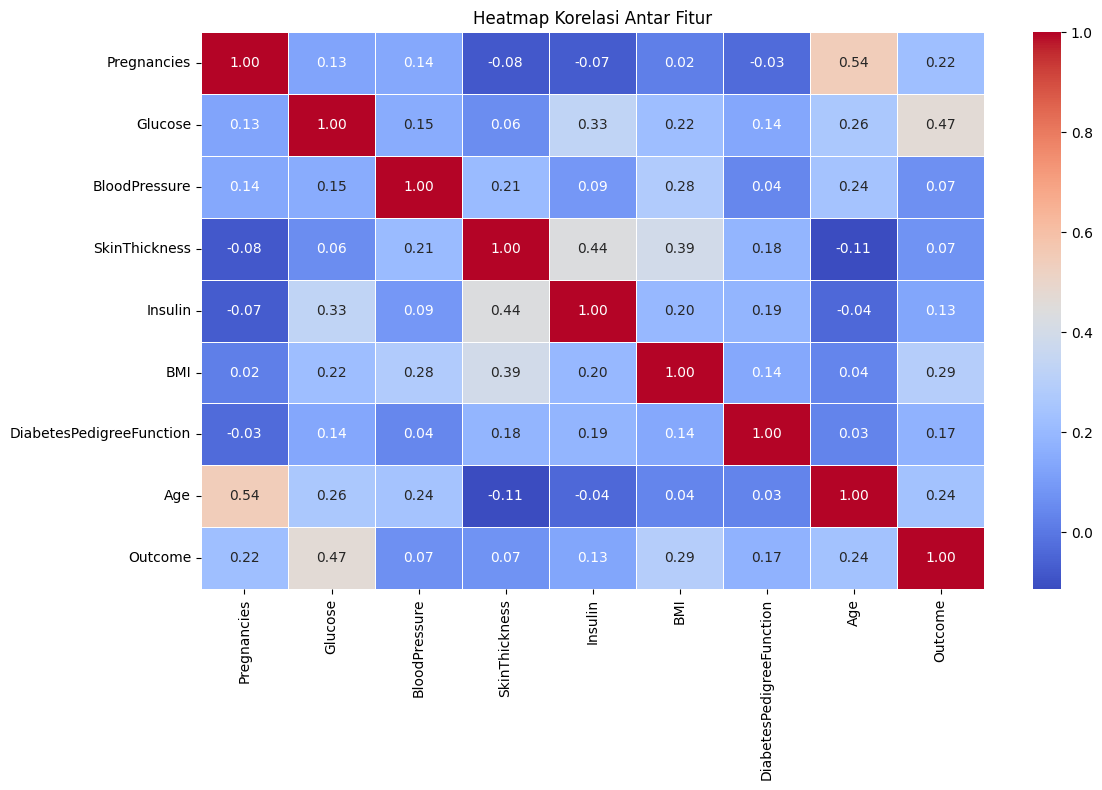

Heatmap korelasi disimpan


In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=150)
plt.show()
print("Heatmap korelasi disimpan")

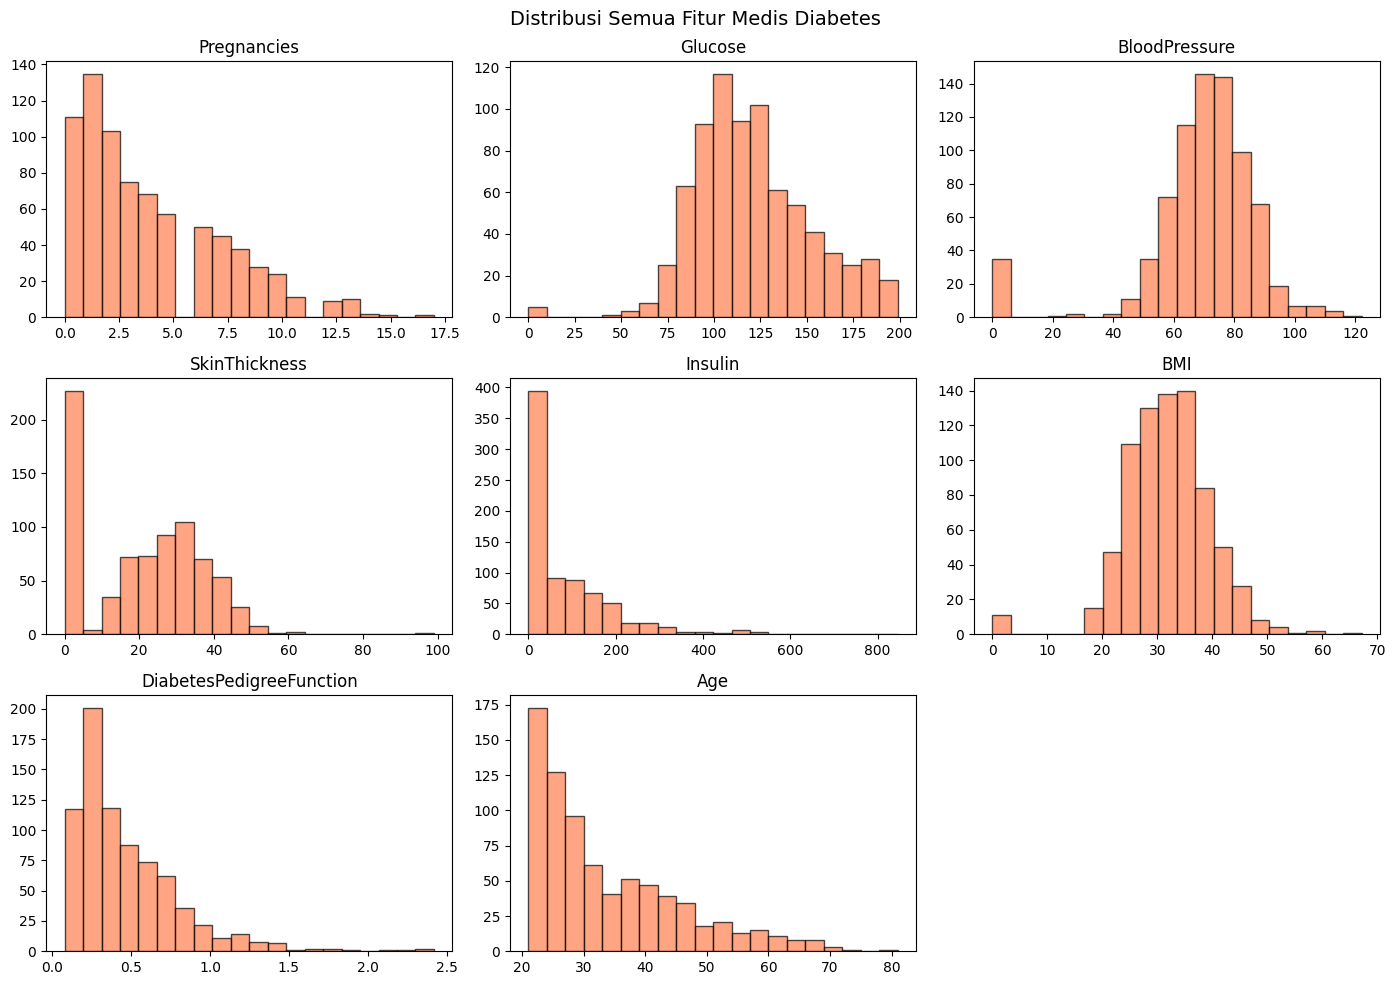

Distribusi semua fitur baru berhasil disimpan!


In [8]:
feature_cols = [col for col in df.columns if col != 'Outcome']
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=20, color='coral', edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
fig.delaxes(axes[8])

plt.suptitle('Distribusi Semua Fitur Medis Diabetes', fontsize=14)
plt.tight_layout()
plt.savefig('distribusi_fitur.png', dpi=150)
plt.show()
print("Distribusi semua fitur baru berhasil disimpan!")

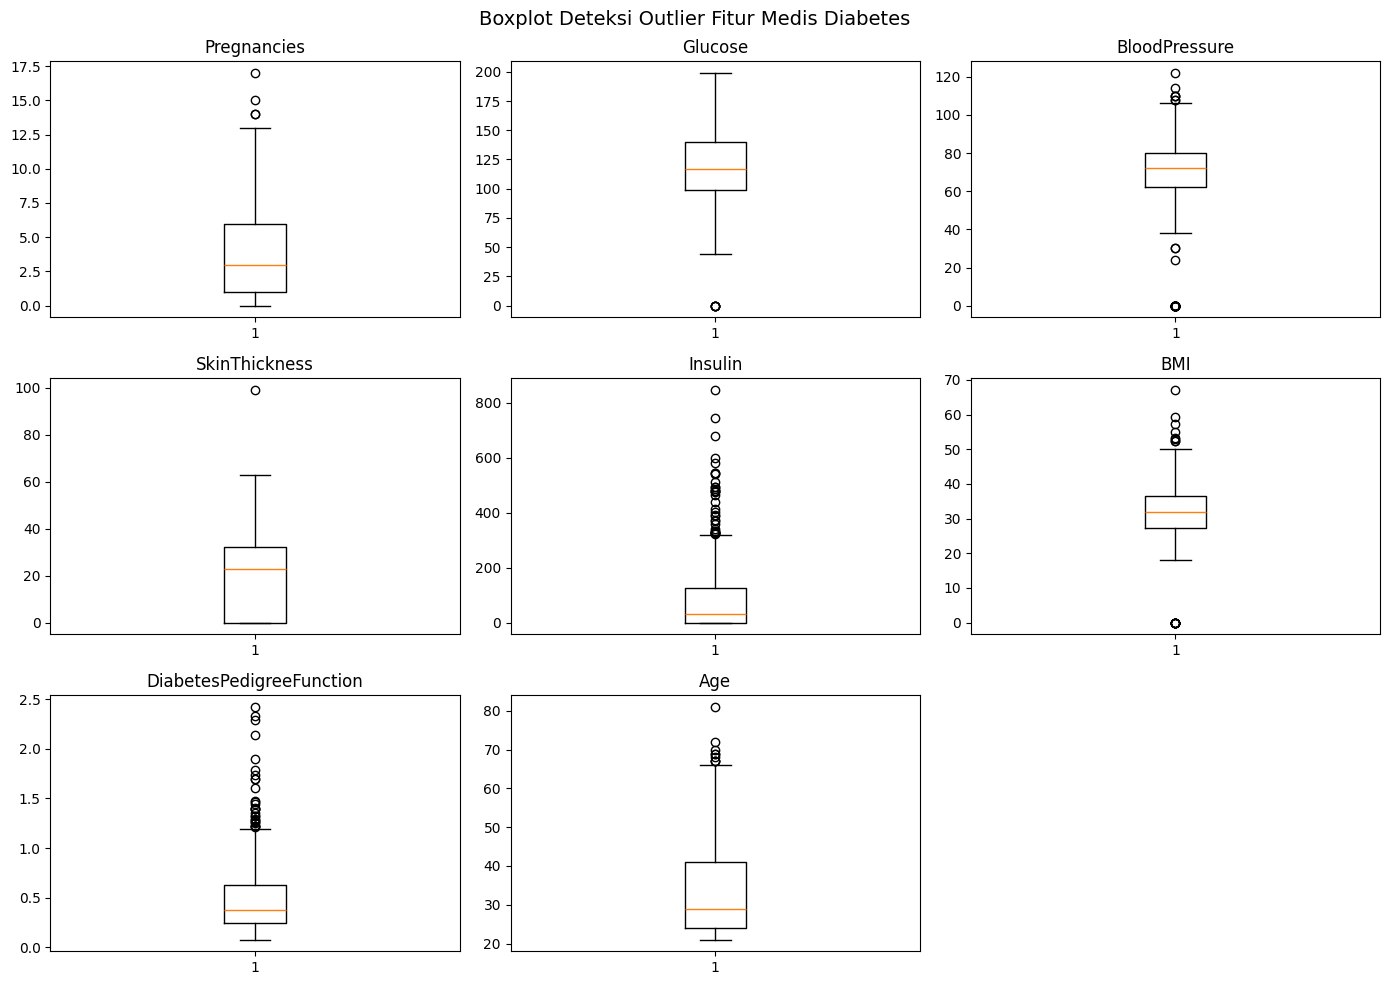

Boxplot outlier baru berhasil disimpan!


In [9]:
feature_cols = [col for col in df.columns if col != 'Outcome']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col)

fig.delaxes(axes[8])

plt.suptitle('Boxplot Deteksi Outlier Fitur Medis Diabetes', fontsize=14)
plt.tight_layout()
plt.savefig('boxplot_outlier.png', dpi=150)
plt.show()
print("Boxplot outlier baru berhasil disimpan!")

### Analisis Hasil Exploratory Data Analysis (EDA):
1. **Distribusi Kelas Target (`Outcome`)**: Data mengalami sedikit ketidakseimbangan (*imbalanced data*), di mana pasien Non-Diabetes (0) berjumlah 500 data dan pasien Diabetes (1) berjumlah 268 data.
2. **Temuan Data Invalid (Missing Values Tersembunyi)**: Berdasarkan deskripsi statistik dan grafik histogram, terdapat nilai `0` yang tidak masuk akal secara medis pada fitur `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, dan `BMI`. Nilai 0 ini diidentifikasi sebagai data kosong yang akan ditangani pada tahap preprocessing menggunakan metode **Median Imputation**.
3. **Deteksi Outlier**: Berdasarkan grafik boxplot, hampir seluruh fitur medis memiliki pencilan (*outlier*) di sisi atas, terutama pada fitur `Insulin` dan `DiabetesPedigreeFunction`. Outlier ini akan dibersihkan menggunakan metode **Interquartile Range (IQR)**.

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [10]:
df_processed = df.copy()

before = df_processed.shape[0]
df_processed = df_processed.drop_duplicates()
after = df_processed.shape[0]
print(f"Hapus duplikat: {before} → {after} baris ({before-after} dihapus)")

invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in invalid_cols:
    df_processed[col] = df_processed[col].replace(0, np.nan)

for col in invalid_cols:
    df_processed[col] = df_processed[col].fillna(df_processed[col].median())
print("Penanganan nilai 0 invalid (Median Imputation) selesai!")

def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean

feature_cols = [col for col in df_processed.columns if col != 'Outcome']
df_processed = remove_outliers_iqr(df_processed, feature_cols)
print(f"Hapus outlier (IQR): {after} → {df_processed.shape[0]} baris")

X = df_processed.drop('Outcome', axis=1)
y = df_processed['Outcome']
print(f"Fitur: {X.shape[1]} kolom | Target: {y.nunique()} kelas unik")
print(f"Distribusi kelas baru:\n{y.value_counts().sort_index()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain set: {X_train.shape[0]} baris | Test set: {X_test.shape[0]} baris")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("Standarisasi fitur (StandardScaler) selesai!")

df_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
df_train_final['Outcome'] = y_train.values

df_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)
df_test_final['Outcome'] = y_test.values

df_train_final.to_csv('diabetes_preprocessing.csv', index=False)
df_test_final.to_csv('diabetes_test.csv', index=False)

print(f"\n Preprocessing selesai dengan sukses!")
print(f" - File disimpan: diabetes_preprocessing.csv ({df_train_final.shape})")
print(f" - File disimpan: diabetes_test.csv ({df_test_final.shape})")

Hapus duplikat: 768 → 768 baris (0 dihapus)
Penanganan nilai 0 invalid (Median Imputation) selesai!
Hapus outlier (IQR): 768 → 332 baris
Fitur: 8 kolom | Target: 2 kelas unik
Distribusi kelas baru:
Outcome
0    217
1    115
Name: count, dtype: int64

Train set: 265 baris | Test set: 67 baris
Standarisasi fitur (StandardScaler) selesai!

 Preprocessing selesai dengan sukses!
 - File disimpan: diabetes_preprocessing.csv ((265, 9))
 - File disimpan: diabetes_test.csv ((67, 9))
